<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 7

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("RAY_DEDUP_LOGS", "0")

import copy
import logging
import random
import time
import warnings
from collections import OrderedDict

import flwr as fl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from flwr.common import ndarrays_to_parameters
from flwr.common.logger import update_console_handler
from IPython.display import display
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')


In [3]:
random_state = 333
# Reproducibility
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)
np.random.seed(random_state)
random.seed(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
flower_device = torch.device('cpu')
print(f'Using device: {device}')
print(f'Using device for Flower simulation: {flower_device}')


Using device: cuda
Using device for Flower simulation: cpu


## Table of Contents

* [Problem 7.1: Federated Learning](#problem-71-federated-learning)
* [Problem 7.2: Differential Privacy](#problem-72-differential-privacy)
* [Problem 7.3: MLOps Pipeline](#problem-73-mlops-pipeline)

## Problem 7.1: Federated Learning

### Objective
Implement federated learning using Flower

### Tasks
- Simulate 5 clients with non-IID data splits (MNIST).
- Implement FedAvg algorithm.
- Track model performance at each communication round.
- Compare with centralized training.

In classical machine learning we usually move all data into one central place. In federated learning the idea is reversed: data stays on clients and only model weights are exchanged. The workflow is:

1. server sends global model weights to clients
2. each client trains local model on its private data, here only for 1 epoch
3. clients send updated weights back to the server
4. server aggregates them with FedAvg
5. the next communication round starts

So the training data never leaves the client. In this exercise we simulate this setup on MNIST.

First we load MNIST. It contains grayscale 28x28 images of handwritten digits from 0 to 9. We use the original train and test split from `torchvision`.

In [4]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(
    root='./../datasets',
    train=True,
    download=True,
    transform=mnist_transform,
)

test_dataset = datasets.MNIST(
    root='./../datasets',
    train=False,
    download=True,
    transform=mnist_transform,
)

batch_size = 128
test_batch_size = 512
num_workers = 0

train_loader_full = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    generator=torch.Generator().manual_seed(random_state),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

sample_images, sample_labels = next(iter(train_loader_full))
print(f'One batch shape: {sample_images.shape}')
print(f'Example labels: {sample_labels[:12].tolist()}')


Train samples: 60000
Test samples: 10000
One batch shape: torch.Size([128, 1, 28, 28])
Example labels: [5, 7, 6, 6, 7, 3, 3, 6, 7, 9, 6, 0]


now lets create non-iid clients. Each client receives only two digits. This is artificial, but it imitates a real case where different users or institutions have different data distributions.

In [5]:
client_digit_groups = {
    0: [0, 1],
    1: [2, 3],
    2: [4, 5],
    3: [6, 7],
    4: [8, 9],
}

train_targets = np.array(train_dataset.targets)
client_indices = []
client_rows = []

for client_id, digits in client_digit_groups.items():
    indices = np.where(np.isin(train_targets, digits))[0]
    rng = np.random.default_rng(random_state + client_id)
    indices = rng.permutation(indices)
    client_indices.append(indices.tolist())

    labels = train_targets[indices]
    row = {'client': f'client {client_id}', 'digits': str(digits), 'samples': len(indices)}
    for digit in range(10):
        row[str(digit)] = int((labels == digit).sum())
    client_rows.append(row)

all_client_indices = np.concatenate([np.array(indices) for indices in client_indices])
print(f'Assigned samples: {len(all_client_indices)}')
print(f'Unique assigned samples: {len(np.unique(all_client_indices))}')
print(f'Train dataset samples: {len(train_dataset)}')

client_distribution_df = pd.DataFrame(client_rows)
display(client_distribution_df)


Assigned samples: 60000
Unique assigned samples: 60000
Train dataset samples: 60000


,client,digits,samples,0,1,2,3,4,5,6,7,8,9
0,client 0,"[0, 1]",12665,5923,6742,0,0,0,0,0,0,0,0
1,client 1,"[2, 3]",12089,0,0,5958,6131,0,0,0,0,0,0
2,client 2,"[4, 5]",11263,0,0,0,0,5842,5421,0,0,0,0
3,client 3,"[6, 7]",12183,0,0,0,0,0,0,5918,6265,0,0
4,client 4,"[8, 9]",11800,0,0,0,0,0,0,0,0,5851,5949


As we see, every client has only two digits and zero examples of the other classes. The full `60000` training samples are still assigned exactly once, but local distributions are very different. This is a strong non-IID split: client 0 can only learn `0/1` locally, client 4 only `8/9`, etc. In real federated learning it can happen when users or institutions naturally collect different kinds of data.

In [6]:
client_loaders = []
for client_id, indices in enumerate(client_indices):
    loader = DataLoader(
        Subset(train_dataset, indices),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )
    client_loaders.append(loader)

print(f'Number of client loaders: {len(client_loaders)}')
print(f'Client dataset sizes: {[len(loader.dataset) for loader in client_loaders]}')


Number of client loaders: 5
Client dataset sizes: [12665, 12089, 11263, 12183, 11800]


Now we define a small convolutional neural network. It is enough for MNIST and it trains quite fast. The output layer has 10 neurons, one for each digit.

In [7]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


dry_model = MNISTCNN().to(device)
dry_model.eval()
with torch.no_grad():
    dry_outputs = dry_model(sample_images[:8].to(device))

print(f'Dry forward output shape: {dry_outputs.shape}')
print(f'Number of model parameters: {sum(p.numel() for p in dry_model.parameters()):,}')
del dry_model


Dry forward output shape: torch.Size([8, 10])
Number of model parameters: 105,866


The helper functions below are used both by Flower clients and by the centralized baseline. Flower works with NumPy arrays, so we also add functions for getting and setting model weights.

In [8]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
local_epochs = 1
num_clients = 5
num_rounds = 5


def get_model_parameters(model):
    return [value.cpu().numpy() for value in model.state_dict().values()]


def set_model_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({key: torch.tensor(value) for key, value in params_dict})
    model.load_state_dict(state_dict, strict=True)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate_model(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


Now we define the Flower client. Every client has its own dataloader and local model. In `fit` it receives global weights, trains locally for one epoch, and returns only updated weights to the server.

In [9]:
class FlowerMNISTClient(fl.client.NumPyClient):
    def __init__(self, client_id, train_loader, local_epochs=1):
        self.client_id = client_id
        self.train_loader = train_loader
        self.local_epochs = local_epochs
        self.model = MNISTCNN().to(flower_device)

    def get_parameters(self, config):
        return get_model_parameters(self.model)

    def fit(self, parameters, config):
        set_model_parameters(self.model, parameters)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)

        train_loss = None
        train_acc = None
        for _ in range(self.local_epochs):
            train_loss, train_acc = train_one_epoch(
                self.model,
                self.train_loader,
                optimizer,
                flower_device,
            )

        return (
            get_model_parameters(self.model),
            len(self.train_loader.dataset),
            {
                'train_loss': float(train_loss),
                'train_acc': float(train_acc),
            },
        )


Before running Flower, we create an initial global model. The same initial weights will also be used by the centralized baseline, so the comparison starts from the same point.

In [10]:
initial_model = MNISTCNN().to(flower_device)
initial_state = copy.deepcopy(initial_model.state_dict())
initial_parameters = ndarrays_to_parameters(get_model_parameters(initial_model))

fl_global_model = MNISTCNN().to(flower_device)
fl_history_rows = []


def evaluate_fn(server_round, parameters, config):
    set_model_parameters(fl_global_model, parameters)
    test_loss, test_acc = evaluate_model(fl_global_model, test_loader, flower_device)
    fl_history_rows.append({
        'round': server_round,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })
    return test_loss, {'accuracy': test_acc}


def fit_metrics_aggregation_fn(metrics):
    total_examples = sum(num_examples for num_examples, _ in metrics)
    aggregated = {}
    for metric_name in ['train_loss', 'train_acc']:
        aggregated[metric_name] = sum(
            num_examples * metric_values[metric_name]
            for num_examples, metric_values in metrics
        ) / total_examples
    return aggregated


def client_fn(context):
    client_id = int(context.node_config['partition-id'])
    return FlowerMNISTClient(
        client_id=client_id,
        train_loader=client_loaders[client_id],
        local_epochs=local_epochs,
    ).to_client()


lets run the federated learning simulation. We use all 5 clients in every round and FedAvg as the aggregation strategy.

In [11]:
update_console_handler(level='ERROR')
logging.getLogger('ray').setLevel(logging.ERROR)

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=num_clients,
    min_available_clients=num_clients,
    evaluate_fn=evaluate_fn,
    initial_parameters=initial_parameters,
    fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
)

start = time.time()
fl_history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=num_clients,
    config=fl.server.ServerConfig(num_rounds=num_rounds),
    strategy=strategy,
    client_resources={'num_cpus': 1, 'num_gpus': 0.0},
    ray_init_args={
        'ignore_reinit_error': True,
        'include_dashboard': False,
        'log_to_driver': False,
        'logging_level': logging.ERROR,
    },
)
fl_elapsed = time.time() - start

try:
    import ray
    if ray.is_initialized():
        ray.shutdown()
except Exception:
    pass

print(f'Flower simulation took {fl_elapsed:.1f} seconds')


Flower simulation took 31.7 seconds


In [12]:
fl_history_df = pd.DataFrame(fl_history_rows)
fl_rounds_df = fl_history_df[fl_history_df['round'] > 0].copy()

fl_display_df = fl_rounds_df.copy()
for col in ['test_loss', 'test_acc']:
    fl_display_df[col] = fl_display_df[col].round(4)

display(fl_display_df)

final_fl_row = fl_rounds_df.iloc[-1]
print(f"Federated final test accuracy: {final_fl_row['test_acc']:.4f}")
print(f"Federated final test loss: {final_fl_row['test_loss']:.4f}")


,round,test_loss,test_acc
1,1,1.9720,0.3461
2,2,1.5445,0.5098
3,3,1.2763,0.6321
4,4,1.1652,0.6354
5,5,1.0872,0.6430


Federated final test accuracy: 0.6430
Federated final test loss: 1.0872


The federated model is learning, but quite slowly. Test accuracy grows from about `0.35` after the first round to about `0.64` after round 5, and loss drops from about `1.97` to `1.09`. This means FedAvg combines useful updates from clients, but the non-IID split makes the task harder. Every local model trains only on two digits, so its update is biased before averaging.

For comparison we now train the same CNN in the normal centralized way. This model sees the full training dataset in every epoch. The number of epochs is equal to the number of federated communication rounds.

In [13]:
centralized_model = MNISTCNN().to(device)
centralized_model.load_state_dict(copy.deepcopy(initial_state))
centralized_optimizer = torch.optim.Adam(centralized_model.parameters(), lr=learning_rate)

centralized_history = []
start = time.time()

for epoch in range(1, num_rounds + 1):
    train_loss, train_acc = train_one_epoch(
        centralized_model,
        train_loader_full,
        centralized_optimizer,
        device,
    )
    test_loss, test_acc = evaluate_model(centralized_model, test_loader, device)

    centralized_history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })

    print(
        f"epoch {epoch}: "
        f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
        f"test loss={test_loss:.4f}, test acc={test_acc:.4f}"
    )

centralized_elapsed = time.time() - start
centralized_history_df = pd.DataFrame(centralized_history)
print(f'Centralized training took {centralized_elapsed:.1f} seconds')

centralized_display_df = centralized_history_df.copy()
for col in ['train_loss', 'train_acc', 'test_loss', 'test_acc']:
    centralized_display_df[col] = centralized_display_df[col].round(4)

display(centralized_display_df)

final_centralized_row = centralized_history_df.iloc[-1]
print(f"Centralized final test accuracy: {final_centralized_row['test_acc']:.4f}")
print(f"Centralized final test loss: {final_centralized_row['test_loss']:.4f}")


epoch 1: train loss=0.3012, train acc=0.9097, test loss=0.0722, test acc=0.9763


epoch 2: train loss=0.0867, train acc=0.9739, test loss=0.0493, test acc=0.9846


epoch 3: train loss=0.0639, train acc=0.9807, test loss=0.0356, test acc=0.9872


epoch 4: train loss=0.0518, train acc=0.9844, test loss=0.0333, test acc=0.9889


epoch 5: train loss=0.0427, train acc=0.9865, test loss=0.0369, test acc=0.9887
Centralized training took 38.7 seconds


,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.3012,0.9098,0.0722,0.9763
1,2,0.0867,0.9739,0.0493,0.9846
2,3,0.0639,0.9807,0.0356,0.9872
3,4,0.0518,0.9844,0.0333,0.9889
4,5,0.0427,0.9865,0.0369,0.9887


Centralized final test accuracy: 0.9887
Centralized final test loss: 0.0369


Centralized training is much stronger here. After only one epoch the test accuracy is already about `0.98`, and after 5 epochs it stays close to `0.99`. The loss is also very small. This happens because the centralized model sees all digits mixed together in every epoch, so it does not have the same client distribution problem.

Finally we compare both approaches on the test set. In the plot, one federated round is compared with one centralized epoch.

In [14]:
comparison_df = pd.DataFrame([
    {
        'method': 'federated',
        'step': int(final_fl_row['round']),
        'test_loss': final_fl_row['test_loss'],
        'test_acc': final_fl_row['test_acc'],
        'time_sec': fl_elapsed,
    },
    {
        'method': 'centralized',
        'step': int(final_centralized_row['epoch']),
        'test_loss': final_centralized_row['test_loss'],
        'test_acc': final_centralized_row['test_acc'],
        'time_sec': centralized_elapsed,
    },
])

comparison_display_df = comparison_df.copy()
for col in ['test_loss', 'test_acc']:
    comparison_display_df[col] = comparison_display_df[col].round(4)
comparison_display_df['time_sec'] = comparison_display_df['time_sec'].round(1)
display(comparison_display_df)


,method,step,test_loss,test_acc,time_sec
0,federated,5,1.0872,0.6430,31.7
1,centralized,5,0.0369,0.9887,38.7


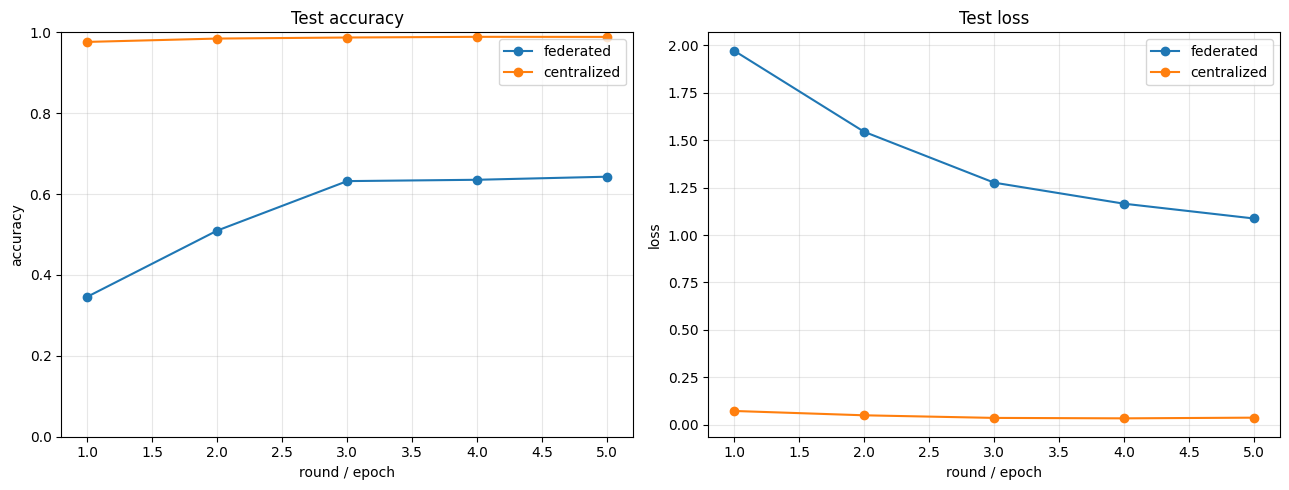

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_acc'],
    marker='o',
    label='federated',
)
axes[0].plot(
    centralized_history_df['epoch'],
    centralized_history_df['test_acc'],
    marker='o',
    label='centralized',
)
axes[0].set_title('Test accuracy')
axes[0].set_xlabel('round / epoch')
axes[0].set_ylabel('accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_loss'],
    marker='o',
    label='federated',
)
axes[1].plot(
    centralized_history_df['epoch'],
    centralized_history_df['test_loss'],
    marker='o',
    label='centralized',
)
axes[1].set_title('Test loss')
axes[1].set_xlabel('round / epoch')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


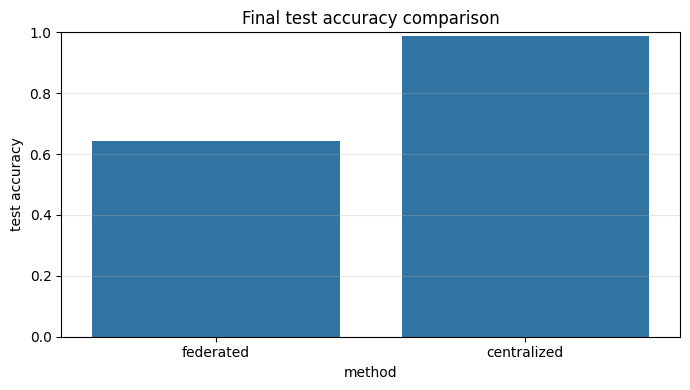

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x='method', y='test_acc')
plt.title('Final test accuracy comparison')
plt.xlabel('method')
plt.ylabel('test accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


One more useful check is to train federated learning for more communication rounds. We keep `local_epochs = 1`, because with non-IID clients too many local epochs can make every client move too much toward its own two digits. Here we only ask: if FedAvg gets more rounds, does it get close to centralized training?

In [17]:
long_num_rounds = 20
long_fl_global_model = MNISTCNN().to(flower_device)
long_fl_history_rows = []

long_initial_model = MNISTCNN().to(flower_device)
long_initial_model.load_state_dict(copy.deepcopy(initial_state))
long_initial_parameters = ndarrays_to_parameters(get_model_parameters(long_initial_model))


def long_evaluate_fn(server_round, parameters, config):
    set_model_parameters(long_fl_global_model, parameters)
    test_loss, test_acc = evaluate_model(long_fl_global_model, test_loader, flower_device)
    long_fl_history_rows.append({
        'round': server_round,
        'test_loss': test_loss,
        'test_acc': test_acc,
    })
    return test_loss, {'accuracy': test_acc}


long_strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=num_clients,
    min_available_clients=num_clients,
    evaluate_fn=long_evaluate_fn,
    initial_parameters=long_initial_parameters,
    fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
)

start = time.time()
long_fl_history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=num_clients,
    config=fl.server.ServerConfig(num_rounds=long_num_rounds),
    strategy=long_strategy,
    client_resources={'num_cpus': 1, 'num_gpus': 0.0},
    ray_init_args={
        'ignore_reinit_error': True,
        'include_dashboard': False,
        'log_to_driver': False,
        'logging_level': logging.ERROR,
    },
)
long_fl_elapsed = time.time() - start

try:
    import ray
    if ray.is_initialized():
        ray.shutdown()
except Exception:
    pass

print(f'Longer Flower simulation took {long_fl_elapsed:.1f} seconds')


Longer Flower simulation took 94.6 seconds


In [18]:
long_fl_history_df = pd.DataFrame(long_fl_history_rows)
long_fl_rounds_df = long_fl_history_df[long_fl_history_df['round'] > 0].copy()

long_fl_display_df = long_fl_rounds_df.copy()
for col in ['test_loss', 'test_acc']:
    long_fl_display_df[col] = long_fl_display_df[col].round(4)

display(long_fl_display_df)

final_long_fl_row = long_fl_rounds_df.iloc[-1]
print(f"Long federated final test accuracy: {final_long_fl_row['test_acc']:.4f}")
print(f"Long federated final test loss: {final_long_fl_row['test_loss']:.4f}")


,round,test_loss,test_acc
1,1,2.0132,0.3595
2,2,1.5808,0.4713
3,3,1.2829,0.6010
4,4,1.1541,0.6584
5,5,1.0338,0.6779
6,6,0.9808,0.6884
7,7,0.8902,0.7235
8,8,0.8387,0.7276
9,9,0.8302,0.7378
10,10,0.8184,0.7380


Long federated final test accuracy: 0.8118
Long federated final test loss: 0.5792


With more communication rounds the federated model improves a lot. Accuracy goes from about `0.36` in round 1 to about `0.81` in round 20, and loss drops from about `2.01` to `0.58`. The curve is not perfectly smooth, but the trend is clearly positive. This suggests that FedAvg can keep learning from these non-IID clients, but it needs many more rounds than the centralized model needs epochs.

In [19]:
long_comparison_df = pd.DataFrame([
    {
        'method': 'federated 5 rounds',
        'test_loss': final_fl_row['test_loss'],
        'test_acc': final_fl_row['test_acc'],
        'time_sec': fl_elapsed,
    },
    {
        'method': 'federated 20 rounds',
        'test_loss': final_long_fl_row['test_loss'],
        'test_acc': final_long_fl_row['test_acc'],
        'time_sec': long_fl_elapsed,
    },
    {
        'method': 'centralized 5 epochs',
        'test_loss': final_centralized_row['test_loss'],
        'test_acc': final_centralized_row['test_acc'],
        'time_sec': centralized_elapsed,
    },
])

long_comparison_display_df = long_comparison_df.copy()
for col in ['test_loss', 'test_acc']:
    long_comparison_display_df[col] = long_comparison_display_df[col].round(4)
long_comparison_display_df['time_sec'] = long_comparison_display_df['time_sec'].round(1)
display(long_comparison_display_df)


,method,test_loss,test_acc,time_sec
0,federated 5 rounds,1.0872,0.6430,31.7
1,federated 20 rounds,0.5792,0.8118,94.6
2,centralized 5 epochs,0.0369,0.9887,38.7


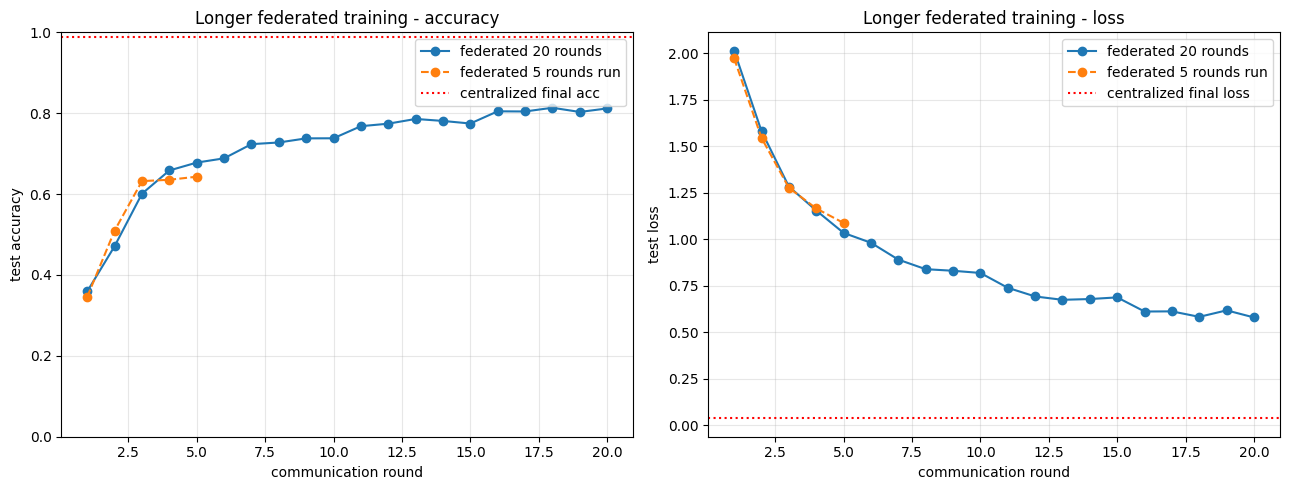

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    long_fl_rounds_df['round'],
    long_fl_rounds_df['test_acc'],
    marker='o',
    label='federated 20 rounds',
)
axes[0].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_acc'],
    marker='o',
    linestyle='--',
    label='federated 5 rounds run',
)
axes[0].axhline(
    final_centralized_row['test_acc'],
    color='red',
    linestyle=':',
    label='centralized final acc',
)
axes[0].set_title('Longer federated training - accuracy')
axes[0].set_xlabel('communication round')
axes[0].set_ylabel('test accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    long_fl_rounds_df['round'],
    long_fl_rounds_df['test_loss'],
    marker='o',
    label='federated 20 rounds',
)
axes[1].plot(
    fl_rounds_df['round'],
    fl_rounds_df['test_loss'],
    marker='o',
    linestyle='--',
    label='federated 5 rounds run',
)
axes[1].axhline(
    final_centralized_row['test_loss'],
    color='red',
    linestyle=':',
    label='centralized final loss',
)
axes[1].set_title('Longer federated training - loss')
axes[1].set_xlabel('communication round')
axes[1].set_ylabel('test loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


The longer run answers the question: more rounds help, but they still do not close the gap. Going from 5 to 20 FL rounds improves accuracy from about `0.64` to about `0.81`. Still, centralized training after only 5 epochs is around `0.99`. So in this setup the bottleneck is not only training time, but also the very strong non-IID split.

### Conclusions

Overall, Flower simulation worked and FedAvg improved the global MNIST model without moving client data to the server. In the short 5-round run it reached only about `0.64` test accuracy, while centralized training reached about `0.99`. The extra 20-round FL run improved the result to about `0.81`, so more communication rounds definitely help. But it still did not get close to centralized learning, mostly because every client has only two digit classes and local updates are very biased.

## Problem 7.2: Differential Privacy

### Objective
Apply differential privacy to neural network training

### Tasks
- Use Opacus library with PyTorch.
- Train on sensitive dataset (e.g., Adult Income).
- Experiment with different epsilon values (1.0, 5.0, 10.0).
- Analyze privacy-utility tradeoff

## Problem 7.3: MLOps Pipeline

### Objective
Build complete ML pipeline

### Tasks
- Track experiments using MLflow.
- Version data with DVC.
- Deploy model as REST API using FastAPI.
- Containerize with Docker.
- Implement basic monitoring for predictions.